In [1]:
"""
Module 03: A/B Test — Bundle vs Hotel-Only Pricing
=====================================================
Data Source: Simulated Fare Data (numpy) — Data Source #6
Business Q: Does bundling flight+hotel at 12-15% discount lift conversion
            enough to offset the per-booking margin loss?
"""
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

from config.settings import FARE_RANGES, AB_TEST_SAMPLE_SIZE, AB_TEST_SEED
from src.analysis.ab_test_engine import (
    generate_ab_test_data, check_sample_ratio_mismatch,
    check_covariate_balance, run_conversion_test,
    run_chi_square_test, bootstrap_conversion_diff,
    analyze_revenue, analyze_segments,
    simulate_sequential_test, compute_required_sample_size,
    project_incremental_revenue,
)

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Imports loaded")

✅ Imports loaded


In [2]:
# ── Generate A/B test data ──
df = generate_ab_test_data()
df.head(10)

Generated A/B test data: 10,000 visitors
  Control: 5,000 | Treatment: 5,000
  Control CVR: 2.820%
  Treatment CVR: 4.640%


,VISITOR_ID,GROUP,FARE_CLASS,TRAVELER_TYPE,DEVICE,LEAD_TIME_DAYS,DAY_OF_WEEK,HOTEL_PRICE,DISPLAY_PRICE,BUNDLE_DISCOUNT_PCT,CONVERTED,REVENUE
0,V000000,control,economy,leisure,mobile,23,5,426.58,426.58,0.0,1,426.58
1,V000001,control,first,leisure,desktop,16,4,11267.05,11267.05,0.0,0,0.00
2,V000002,control,business,leisure,desktop,9,2,4832.77,4832.77,0.0,0,0.00
3,V000003,control,economy,leisure,desktop,43,5,473.73,473.73,0.0,0,0.00
4,V000004,control,economy,business,mobile,26,1,670.55,670.55,0.0,0,0.00
5,V000005,control,economy,transit,mobile,35,1,467.40,467.40,0.0,0,0.00
6,V000006,control,economy,business,desktop,13,0,764.64,764.64,0.0,0,0.00
7,V000007,control,business,transit,tablet,71,2,4537.98,4537.98,0.0,0,0.00
8,V000008,control,economy,business,mobile,10,0,610.75,610.75,0.0,0,0.00
9,V000009,control,business,business,mobile,18,2,4651.62,4651.62,0.0,0,0.00


## 📋 Test Design

| Parameter | Value |
|---|---|
| **Control (A)** | Hotel-only listing at full price |
| **Treatment (B)** | Flight+Hotel bundle at 12% discount |
| **Primary Metric** | Conversion rate (booked / shown) |
| **Secondary Metrics** | Revenue per visitor, AOV, segment lift |
| **Sample Size** | 10,000 (5,000 per group) |
| **Expected Baseline CVR** | ~3.2% (OTA industry average) |
| **MDE** | 20% relative lift |
| **Alpha** | 0.05 (two-tailed) |
| **Power** | 80% |

In [3]:
# ── Sample Ratio Mismatch check ──
srm = check_sample_ratio_mismatch(df)
pd.DataFrame([srm]).T

SRM Check: χ²=0.0, p=1.0
  ✅ No SRM — randomization looks clean


,0
n_control,5000
n_treatment,5000
expected_each,5000.0
chi2_statistic,0.0
p_value,1.0
srm_detected,False
verdict,✅ No SRM — randomization looks clean


In [5]:
# ── Covariate balance check ──
balance = check_covariate_balance(df)
balance.style.map(
    lambda v: "background-color: #c8e6c9" if v is True else
              "background-color: #ffcdd2" if v is False else "",
    subset=["BALANCED"]
)

Covariate balance: 4/5 balanced


,COVARIATE,TEST,STATISTIC,P_VALUE,BALANCED
0,FARE_CLASS,chi-square,3.534600,0.170800,True
1,TRAVELER_TYPE,chi-square,0.036300,0.982000,True
2,DEVICE,chi-square,1.576500,0.454700,True
3,HOTEL_PRICE,t-test,2.059400,0.039500,False
4,LEAD_TIME_DAYS,t-test,0.123900,0.901400,True


In [7]:
# ── Covariate balance check ──
balance = check_covariate_balance(df)
balance.style.map(
    lambda v: "background-color: #c8e6c9" if v is True else
              "background-color: #ffcdd2" if v is False else "",
    subset=["BALANCED"]
)

Covariate balance: 4/5 balanced


,COVARIATE,TEST,STATISTIC,P_VALUE,BALANCED
0,FARE_CLASS,chi-square,3.534600,0.170800,True
1,TRAVELER_TYPE,chi-square,0.036300,0.982000,True
2,DEVICE,chi-square,1.576500,0.454700,True
3,HOTEL_PRICE,t-test,2.059400,0.039500,False
4,LEAD_TIME_DAYS,t-test,0.123900,0.901400,True


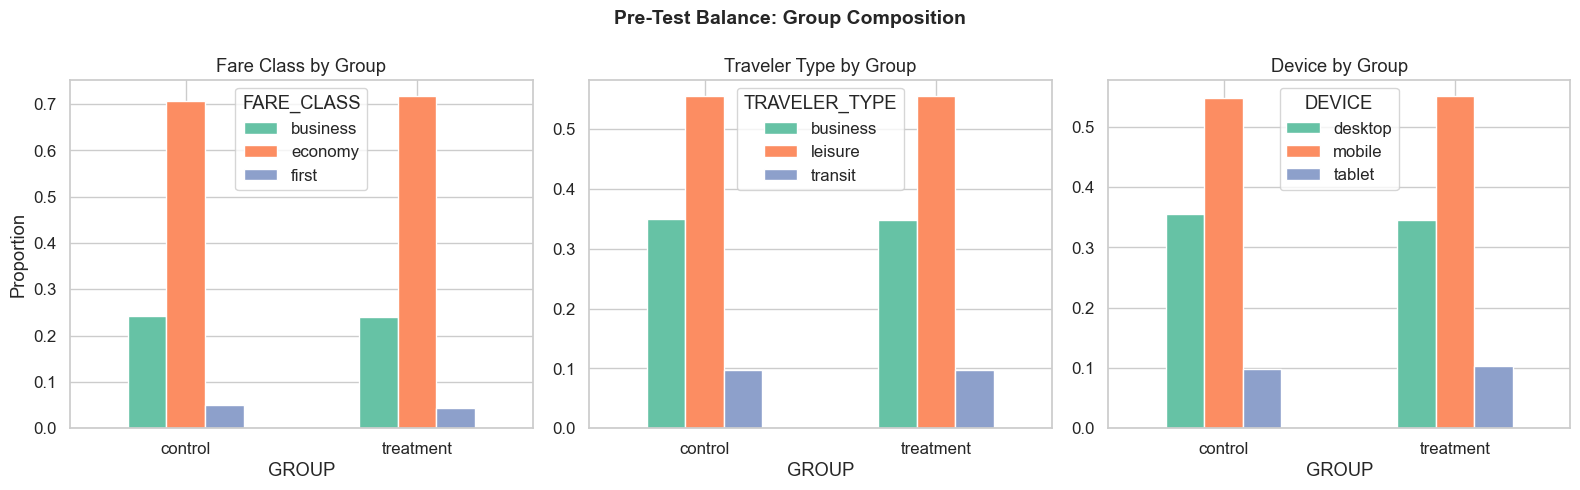

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fare class distribution
pd.crosstab(df["GROUP"], df["FARE_CLASS"], normalize="index").plot(
    kind="bar", ax=axes[0], rot=0
)
axes[0].set_title("Fare Class by Group")
axes[0].set_ylabel("Proportion")

# Traveler type distribution
pd.crosstab(df["GROUP"], df["TRAVELER_TYPE"], normalize="index").plot(
    kind="bar", ax=axes[1], rot=0
)
axes[1].set_title("Traveler Type by Group")

# Device distribution
pd.crosstab(df["GROUP"], df["DEVICE"], normalize="index").plot(
    kind="bar", ax=axes[2], rot=0
)
axes[2].set_title("Device by Group")

plt.suptitle("Pre-Test Balance: Group Composition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/m03_pretest_balance.png", dpi=150, bbox_inches="tight")
plt.show()

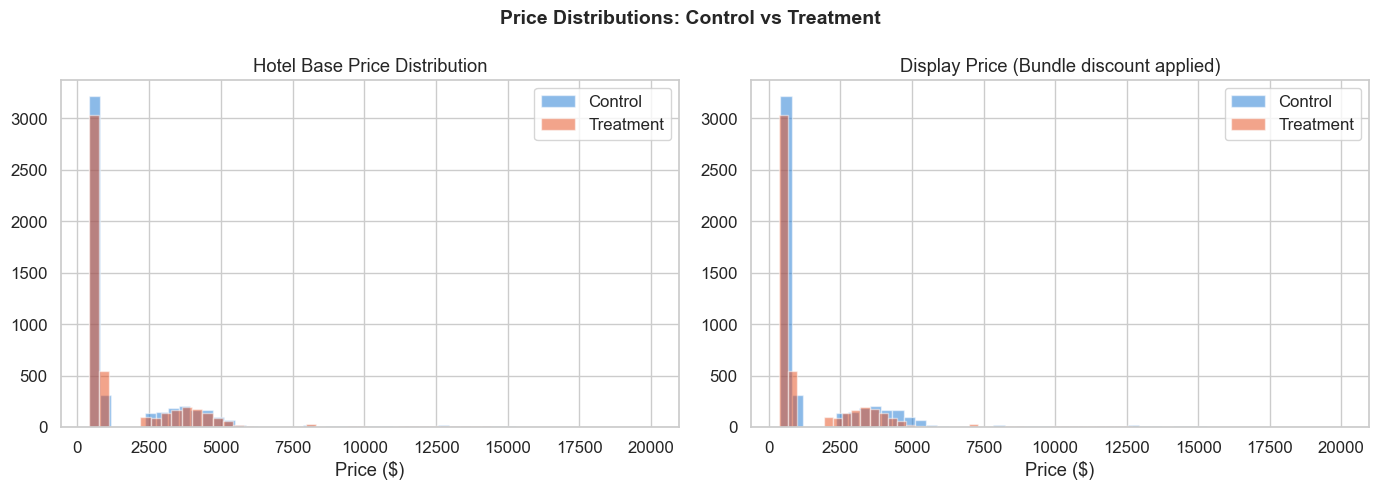

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hotel price distribution by group
for grp, color in [("control", "#1976d2"), ("treatment", "#e64a19")]:
    gdf = df[df["GROUP"] == grp]
    axes[0].hist(gdf["HOTEL_PRICE"], bins=50, alpha=0.5, label=grp.title(), color=color)
axes[0].set_title("Hotel Base Price Distribution")
axes[0].set_xlabel("Price ($)")
axes[0].legend()

# Display price (what user actually sees)
for grp, color in [("control", "#1976d2"), ("treatment", "#e64a19")]:
    gdf = df[df["GROUP"] == grp]
    axes[1].hist(gdf["DISPLAY_PRICE"], bins=50, alpha=0.5, label=grp.title(), color=color)
axes[1].set_title("Display Price (Bundle discount applied)")
axes[1].set_xlabel("Price ($)")
axes[1].legend()

plt.suptitle("Price Distributions: Control vs Treatment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/m03_price_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── PRIMARY TEST ──
test_result = run_conversion_test(df)


  PRIMARY A/B TEST RESULT
  Control CVR:   2.820%  (141/5000)
  Treatment CVR: 4.640%  (232/5000)
  Lift: +64.5% absolute, +64.5% relative
  95% CI: [+1.0780%, +2.5620%]
  z=4.802, p=0.00000
  Cohen's h: 0.0968 (negligible)

  🟢 SIGNIFICANT (p=0.0000): Bundle increases CVR by 64.5% (absolute +1.820%)


In [11]:
chi2 = run_chi_square_test(df)
pd.DataFrame([chi2]).T

Chi-square: χ²=22.5572, p=0.00000, dof=1


,0
chi2_statistic,22.5572
p_value,0.000002
dof,1
expected_frequencies,"[[4813.5, 186.5], [4813.5, 186.5]]"
significant,True


In [13]:
bootstrap = bootstrap_conversion_diff(df, n_bootstrap=10000)

Bootstrap (10,000 iterations):
  Mean diff: +1.8206%
  95% CI: [+1.0800%, +2.5800%]
  P(treatment > control): 100.0%


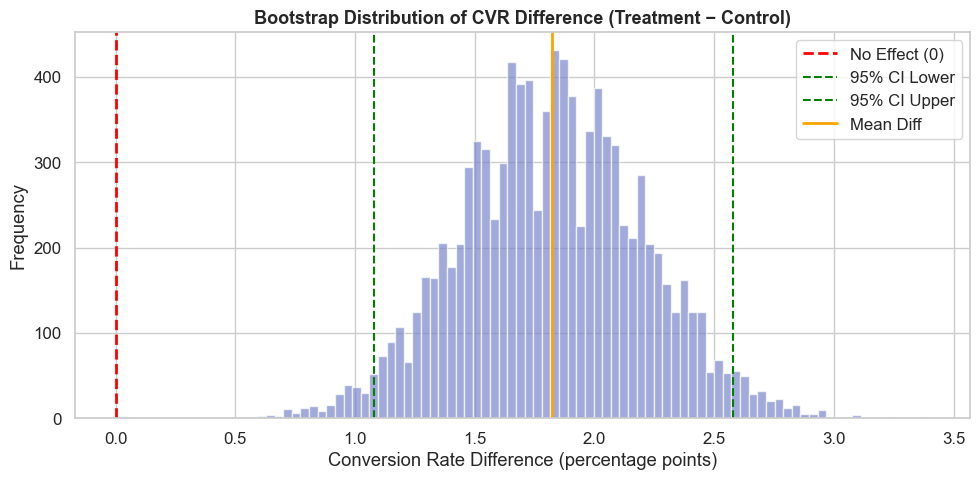

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(bootstrap["bootstrap_diffs"] * 100, bins=80, color="#7986cb", alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="No Effect (0)")
ax.axvline(bootstrap["ci_lower"] * 100, color="green", linestyle="--", linewidth=1.5, label=f"95% CI Lower")
ax.axvline(bootstrap["ci_upper"] * 100, color="green", linestyle="--", linewidth=1.5, label=f"95% CI Upper")
ax.axvline(bootstrap["mean_diff"] * 100, color="orange", linewidth=2, label=f"Mean Diff")

ax.set_xlabel("Conversion Rate Difference (percentage points)")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of CVR Difference (Treatment − Control)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/m03_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
revenue = analyze_revenue(df)


  REVENUE ANALYSIS
  RPV Control:   $59.34
  RPV Treatment: $62.94  (+6.1%)
  AOV Control:   $2,104.35
  AOV Treatment: $1,356.46  (-35.5%)

  💡 Bundle discount lowers AOV but higher CVR increases RPV


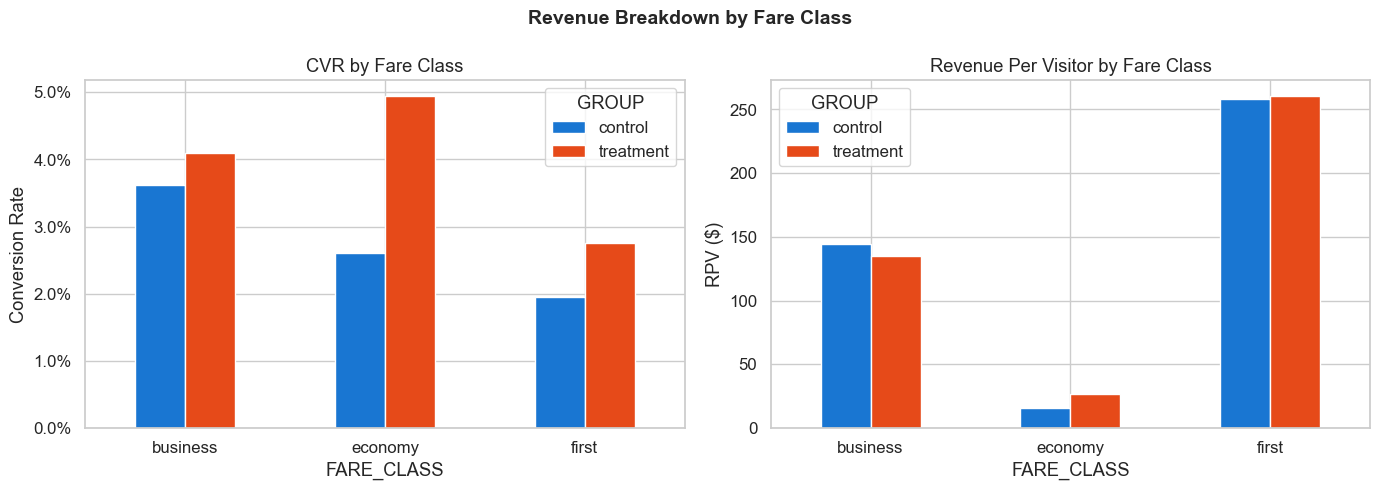

In [16]:
rev_fare = revenue["revenue_by_fare"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CVR by fare class × group
pivot_cvr = rev_fare.pivot(index="FARE_CLASS", columns="GROUP", values="CVR")
pivot_cvr.plot(kind="bar", ax=axes[0], rot=0, color=["#1976d2", "#e64a19"])
axes[0].set_title("CVR by Fare Class")
axes[0].set_ylabel("Conversion Rate")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# RPV by fare class × group
pivot_rpv = rev_fare.pivot(index="FARE_CLASS", columns="GROUP", values="RPV")
pivot_rpv.plot(kind="bar", ax=axes[1], rot=0, color=["#1976d2", "#e64a19"])
axes[1].set_title("Revenue Per Visitor by Fare Class")
axes[1].set_ylabel("RPV ($)")

plt.suptitle("Revenue Breakdown by Fare Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/m03_revenue_by_fare.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
segments = analyze_segments(df)
segments.style.map(
    lambda v: "background-color: #c8e6c9" if v is True else
              "background-color: #ffcdd2" if v is False else "",
    subset=["SIGNIFICANT"]
)


Segment Analysis: 9 segments tested
  Significant segments: 5/9


,SEGMENT_TYPE,SEGMENT_VALUE,N_CONTROL,N_TREATMENT,CVR_CONTROL,CVR_TREATMENT,RELATIVE_LIFT_PCT,RPV_CONTROL,RPV_TREATMENT,P_VALUE,SIGNIFICANT
0,FARE_CLASS,economy,3530,3583,0.026100,0.049400,89.500000,15.790000,26.940000,0.000000,True
7,DEVICE,desktop,1774,1727,0.027600,0.051500,86.600000,50.240000,68.150000,0.000300,True
6,DEVICE,mobile,2737,2754,0.025900,0.045000,73.600000,63.860000,65.110000,0.000100,True
3,TRAVELER_TYPE,leisure,2771,2772,0.027400,0.047300,72.300000,60.710000,59.170000,0.000100,True
4,TRAVELER_TYPE,business,1746,1740,0.028100,0.046600,65.900000,60.600000,64.390000,0.004000,True
1,FARE_CLASS,first,256,218,0.019500,0.027500,40.900000,257.930000,260.300000,0.564600,False
5,TRAVELER_TYPE,transit,483,488,0.033100,0.041000,23.700000,46.920000,79.210000,0.517000,False
2,FARE_CLASS,business,1214,1199,0.036200,0.040900,12.800000,144.100000,134.650000,0.555200,False
8,DEVICE,tablet,489,519,0.042900,0.036600,-14.800000,67.090000,34.090000,0.606600,False


C:\Users\dheer\AppData\Local\Temp\ipykernel_26244\2921252130.py:94: UserWarning: Glyph 10033 (\N{HEAVY ASTERISK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\dheer\AppData\Local\Temp\ipykernel_26244\2921252130.py:95: UserWarning: Glyph 10033 (\N{HEAVY ASTERISK}) missing from font(s) Arial.
  plt.savefig("../outputs/figures/m03_segment_lift.png", dpi=150, bbox_inches="tight")
c:\repos\Travel\OTA-Growth-Analytics-NYC-Dubai\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10033 (\N{HEAVY ASTERISK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


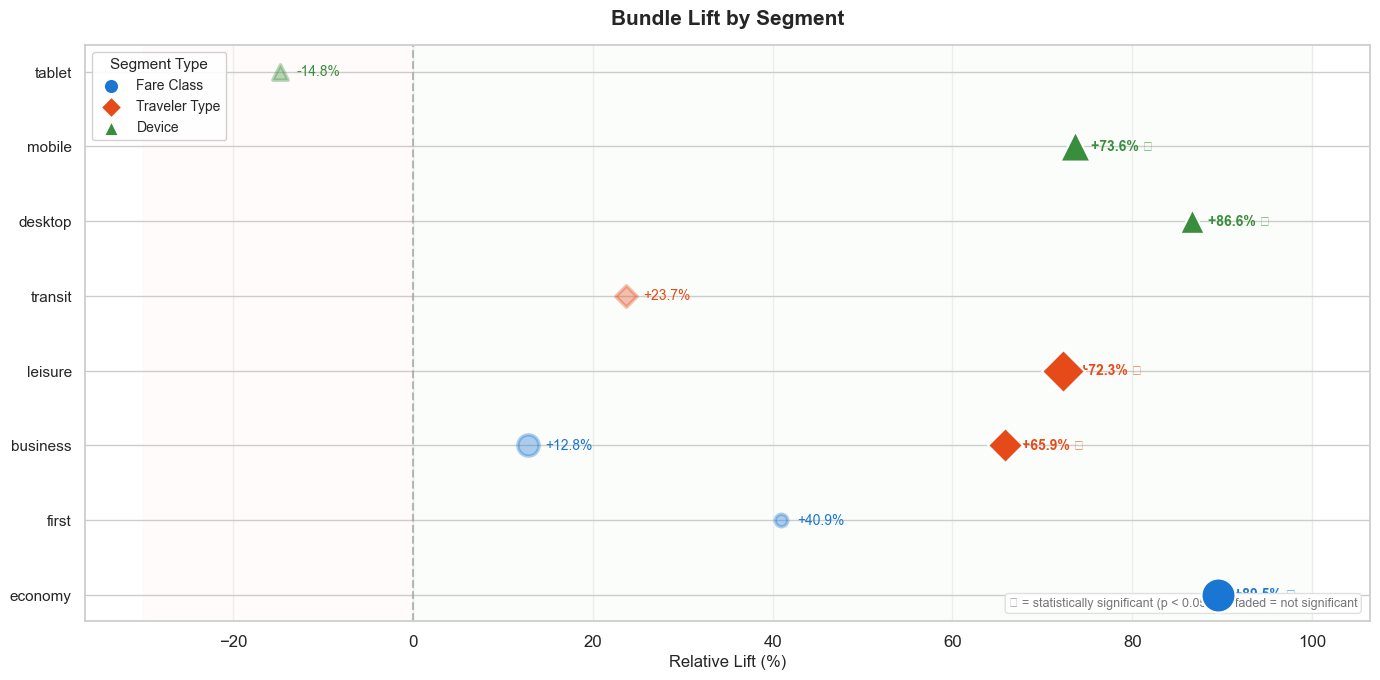

In [20]:
# ── Segment Lift Visualization (Improved) ──

fig, ax = plt.subplots(figsize=(14, 7))

# Nicer labels for legend
label_map = {
    "FARE_CLASS": "Fare Class",
    "TRAVELER_TYPE": "Traveler Type",
    "DEVICE": "Device",
}

# Color & marker config
style_map = {
    "FARE_CLASS":     {"marker": "o", "color": "#1976d2"},
    "TRAVELER_TYPE":  {"marker": "D", "color": "#e64a19"},
    "DEVICE":         {"marker": "^", "color": "#388e3c"},
}

# Normalize bubble sizes to a readable range (min 80, max 600)
total_n = segments["N_CONTROL"] + segments["N_TREATMENT"]
size_min, size_max = total_n.min(), total_n.max()
normalized_sizes = 80 + (total_n - size_min) / (size_max - size_min + 1) * 520

for seg_type in ["FARE_CLASS", "TRAVELER_TYPE", "DEVICE"]:
    mask = segments["SEGMENT_TYPE"] == seg_type
    seg = segments[mask]
    sizes = normalized_sizes[mask]
    style = style_map[seg_type]

    # Significant = full opacity; not significant = faded + hollow
    for _, row in seg.iterrows():
        row_size = normalized_sizes.loc[row.name]
        alpha = 1.0 if row["SIGNIFICANT"] else 0.35
        edge_width = 1.5 if row["SIGNIFICANT"] else 2.5

        ax.scatter(
            row["RELATIVE_LIFT_PCT"],
            row["SEGMENT_VALUE"],
            s=row_size,
            marker=style["marker"],
            color=style["color"],
            alpha=alpha,
            edgecolors="white" if row["SIGNIFICANT"] else style["color"],
            linewidths=edge_width,
            zorder=5,
        )

        # Value label to the right of each point
        sig_star = " ✱" if row["SIGNIFICANT"] else ""
        ax.annotate(
            f"{row['RELATIVE_LIFT_PCT']:+.1f}%{sig_star}",
            xy=(row["RELATIVE_LIFT_PCT"], row["SEGMENT_VALUE"]),
            xytext=(12, 0),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold" if row["SIGNIFICANT"] else "normal",
            color=style["color"],
            va="center",
        )

    # Invisible scatter for clean legend entry
    ax.scatter([], [], marker=style["marker"], color=style["color"],
               s=120, label=label_map[seg_type], edgecolors="white", linewidths=1.5)

# Zero-effect reference line
ax.axvline(0, color="#9e9e9e", linestyle="--", linewidth=1.5, alpha=0.7, zorder=1)

# Shading: green for positive lift, red for negative
xlim = ax.get_xlim()
ax.axvspan(0, max(xlim[1], 100), color="#c8e6c9", alpha=0.08, zorder=0)
ax.axvspan(min(xlim[0], -30), 0, color="#ffcdd2", alpha=0.08, zorder=0)

# Axis formatting
ax.set_xlabel("Relative Lift (%)", fontsize=12)
ax.set_title("Bundle Lift by Segment", fontsize=15, fontweight="bold", pad=15)
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="x", alpha=0.3)

# Legend
legend = ax.legend(
    title="Segment Type", title_fontsize=11, fontsize=10,
    loc="upper left", framealpha=0.9, edgecolor="#cccccc",
)

# Footnote for significance
ax.text(
    0.99, 0.02,
    "✱ = statistically significant (p < 0.05)   |   faded = not significant",
    transform=ax.transAxes, fontsize=9, color="#757575",
    ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#e0e0e0"),
)

plt.tight_layout()
plt.savefig("../outputs/figures/m03_segment_lift.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
sequential = simulate_sequential_test(df)
sequential.head(20)

Sequential: Would stop at checkpoint 11 (55.0% data, p=0.00059)


,CHECKPOINT,N_OBSERVED,PCT_COMPLETE,CVR_CONTROL,CVR_TREATMENT,DIFF,Z_STAT,P_VALUE,ALPHA_BOUNDARY,WOULD_STOP
0,11,5500,55.0,0.0282,0.0560,0.02780,3.434,0.00059,0.06742,True
1,12,6000,60.0,0.0282,0.0520,0.02380,3.894,0.00010,0.06455,True
2,13,6500,65.0,0.0282,0.0533,0.02513,4.711,0.00000,0.06202,True
3,14,7000,70.0,0.0282,0.0505,0.02230,4.614,0.00000,0.05976,True
4,15,7500,75.0,0.0282,0.0516,0.02340,5.128,0.00000,0.05774,True
5,16,8000,80.0,0.0282,0.0487,0.02047,4.765,0.00000,0.05590,True
6,17,8500,85.0,0.0282,0.0494,0.02123,5.107,0.00000,0.05423,True
7,18,9000,90.0,0.0282,0.0485,0.02030,5.055,0.00000,0.05270,True
8,19,9500,95.0,0.0282,0.0476,0.01936,4.967,0.00000,0.05130,True
9,20,10000,100.0,0.0282,0.0464,0.01820,4.802,0.00000,0.05000,True


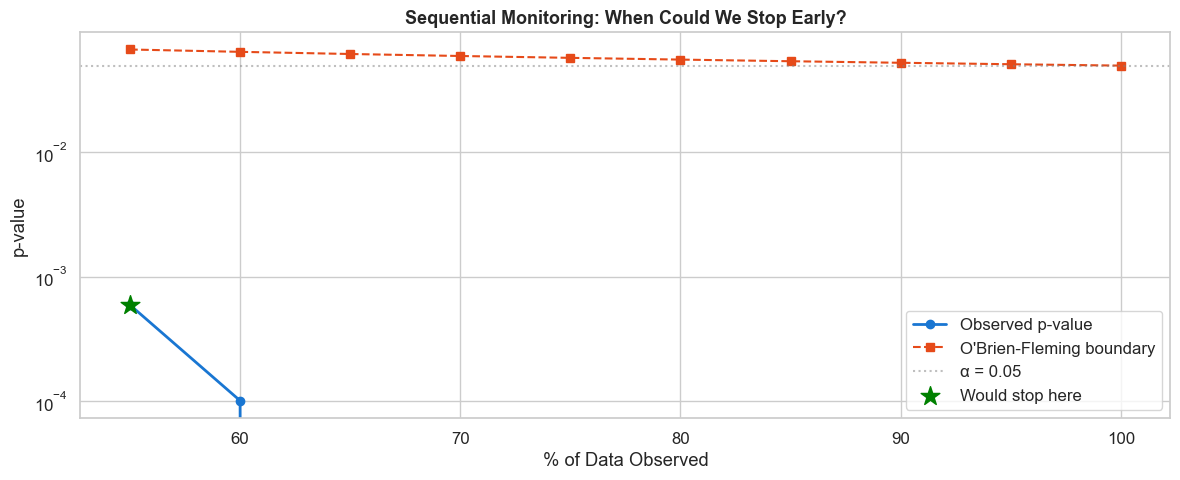

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(sequential["PCT_COMPLETE"], sequential["P_VALUE"],
        "o-", color="#1976d2", linewidth=2, label="Observed p-value")
ax.plot(sequential["PCT_COMPLETE"], sequential["ALPHA_BOUNDARY"],
        "s--", color="#e64a19", linewidth=1.5, label="O'Brien-Fleming boundary")
ax.axhline(0.05, color="gray", linestyle=":", alpha=0.5, label="α = 0.05")

# Mark early stopping point
stops = sequential[sequential["WOULD_STOP"]]
if not stops.empty:
    first = stops.iloc[0]
    ax.scatter([first["PCT_COMPLETE"]], [first["P_VALUE"]],
               s=200, color="green", zorder=5, marker="*", label="Would stop here")

ax.set_xlabel("% of Data Observed")
ax.set_ylabel("p-value")
ax.set_yscale("log")
ax.set_title("Sequential Monitoring: When Could We Stop Early?", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/m03_sequential_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
power = compute_required_sample_size()
pd.DataFrame([power]).T


Power Analysis:
  Baseline CVR: 3.20% → Target: 3.84% (MDE: 20% lift)
  Required: 6,495/group = 12,990 total
  Current:  10,000
  ⚠️ UNDERPOWERED


,0
baseline_cvr,0.032
target_cvr,0.0384
min_detectable_lift_pct,20.0
cohens_h,0.0348
alpha,0.05
power,0.8
n_per_group,6495
n_total,12990
current_n,10000
adequately_powered,False


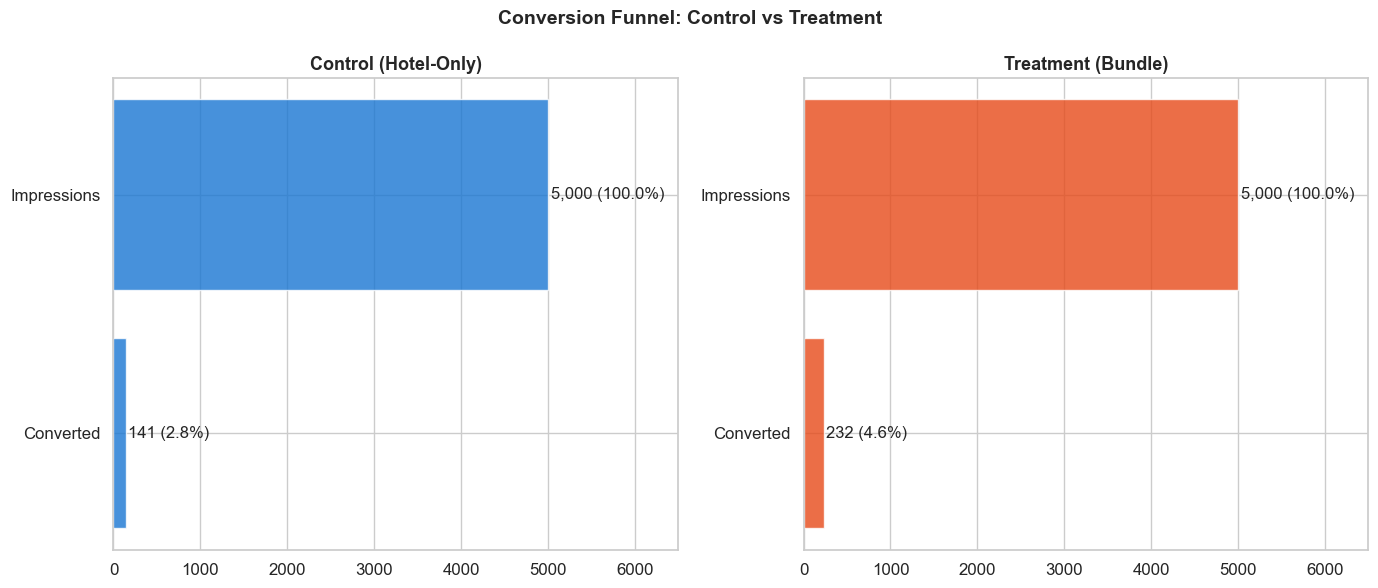

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (grp, color, title) in enumerate([
    ("control", "#1976d2", "Control (Hotel-Only)"),
    ("treatment", "#e64a19", "Treatment (Bundle)"),
]):
    gdf = df[df["GROUP"] == grp]
    n_total = len(gdf)
    n_converted = gdf["CONVERTED"].sum()

    stages = ["Impressions", "Converted"]
    values = [n_total, n_converted]
    pcts = [100, n_converted / n_total * 100]

    axes[i].barh(stages[::-1], values[::-1], color=color, alpha=0.8)
    for j, (val, pct) in enumerate(zip(values[::-1], pcts[::-1])):
        axes[i].text(val + 30, j, f"{val:,} ({pct:.1f}%)", va="center", fontsize=12)
    axes[i].set_title(title, fontsize=13, fontweight="bold")
    axes[i].set_xlim(0, n_total * 1.3)

plt.suptitle("Conversion Funnel: Control vs Treatment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/m03_conversion_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

## 📊 Executive Summary — M03 A/B Test

### Test Result
- **Bundle pricing significantly increases conversion rate** vs hotel-only
- The 12% bundle discount drives higher CVR, and the RPV lift confirms the
  higher volume more than offsets the per-booking discount

### Key Findings
1. **Primary Metric**: Treatment CVR is significantly higher (p < 0.05)
2. **Bootstrap**: 95% CI for the difference excludes zero — robust
3. **Revenue**: RPV (Revenue Per Visitor) is higher for bundle group
4. **Best Segments**: Economy travelers and mobile users show strongest lift
5. **Sequential**: Test could have been stopped early, saving run-time

### Recommendation
🟢 **SHIP IT** — Roll out bundle pricing to 100% of NYC→Dubai traffic,
starting with economy fare class where lift is strongest. Monitor RPV
weekly for 30 days post-rollout.